# Parkinson — Tutarsızlık + Geçiş Profili Özellik Mühendisliği

**Yaklaşım:**
- **Temel özellikler (52):** Weighted mean + weighted std (6. hafta yaklaşımı)
- **Tutarsızlık özellikleri (26):** Her özellik için kayıtlar arası CV (std/mean)
- **Geçiş profili özellikleri (52):** vowel→number farkı + number→sentence/word farkı
- **Toplam: 130 özellik** → multi-filter ile en ayırt edici k tanesi seçilir

**Hipotez:** Parkinson hastalarında ses bozulması hem kayıtlar içinde tutarsız hem de ses tipleri arasındaki geçişlerde farklı bir örüntü sergiliyor.

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, matthews_corrcoef, confusion_matrix

np.random.seed(42)
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [ ]:
# ============================================================
# VERİ YÜKLEME
# ============================================================

print('train_data.txt dosyasını yükle:')
uploaded = files.upload()
TRAIN_PATH = list(uploaded.keys())[0]

FEATURE_NAMES = [
    'Jitter_local', 'Jitter_local_abs', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5',
    'Shimmer_apq11', 'Shimmer_dda',
    'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Frac_unvoiced_frames', 'Num_voice_breaks', 'Degree_voice_breaks'
]

# Ses tipi etiketleri (kayıt sırası)
# 1-3: vowel, 4-13: number, 14-17: sentence, 18-26: word
SAMPLE_TYPES = (
    ['vowel'] * 3 +
    ['number'] * 10 +
    ['sentence'] * 4 +
    ['word'] * 9
)

df = pd.read_csv(TRAIN_PATH, header=None)
df.columns = ['subject_id'] + FEATURE_NAMES + ['UPDRS', 'class']

# Her subject için kayıt numarası (1-26)
df['sample_no'] = df.groupby('subject_id').cumcount() + 1
df['sample_type'] = df['sample_no'].apply(lambda x: SAMPLE_TYPES[x-1])

print(f'Veri boyutu: {df.shape}')
print(f'Subject sayısı: {df["subject_id"].nunique()}')
print(f'Sınıf dağılımı: {df.groupby("subject_id")["class"].first().value_counts().to_dict()}')
print(f'Ses tipi dağılımı:\n{df["sample_type"].value_counts()}')

train_data.txt dosyasını yükle:


Saving train_data.txt to train_data.txt
Veri boyutu: (1040, 31)
Subject sayısı: 40
Sınıf dağılımı: {1: 20, 0: 20}
Ses tipi dağılımı:
sample_type
number      400
word        360
sentence    160
vowel       120
Name: count, dtype: int64


In [ ]:
# ============================================================
# BÖLÜM 1: TEMEL ÖZELLİKLER (52)
# Weighted mean + weighted std — 6. hafta yaklaşımı
# ============================================================

def compute_base_features(subject_df, vowel_w=1.5, number_w=1.2, other_w=1.0):
    """
    Her subject için weighted mean + weighted std hesaplar.
    Robust z-score ile kayıt kalitesi ağırlığı + ses tipi ağırlığı.
    """
    X = subject_df[FEATURE_NAMES].values.astype(float)
    types = subject_df['sample_type'].values
    eps = 1e-8

    # Robust z-score tabanlı kalite ağırlığı
    med = np.median(X, axis=0)
    mad = np.median(np.abs(X - med), axis=0) + eps
    robust_z = np.abs((X - med) / mad)
    anomaly_score = robust_z.mean(axis=1)
    quality_weights = np.exp(-anomaly_score)

    # Ses tipi ağırlığı
    type_weights = np.where(types == 'vowel', vowel_w,
                   np.where(types == 'number', number_w, other_w))

    # Nihai ağırlıklar
    weights = quality_weights * type_weights
    weights = weights / (weights.sum() + eps)

    wmean = (X * weights[:, None]).sum(axis=0)
    wvar = ((X - wmean) ** 2 * weights[:, None]).sum(axis=0)
    wstd = np.sqrt(wvar)

    return wmean, wstd


print('Temel özellik fonksiyonu hazır (weighted mean + weighted std).')

Temel özellik fonksiyonu hazır (weighted mean + weighted std).


In [ ]:
# ============================================================
# BÖLÜM 2: TUTARSIZLIK ÖZELLİKLERİ (26)
# Kayıtlar arası CV (Coefficient of Variation = std / mean)
# Her özellik için kayıtlar arasındaki değişkenlik
# Hipotez: Parkinson hastalarında bu değişkenlik farklı
# ============================================================

def compute_inconsistency_features(subject_df):
    """
    Her özellik için tüm kayıtlar arasındaki CV değerini hesaplar.
    CV = std / (|mean| + eps)
    Yüksek CV → kayıtlar arası yüksek tutarsızlık
    """
    X = subject_df[FEATURE_NAMES].values.astype(float)
    eps = 1e-8

    feat_mean = X.mean(axis=0)
    feat_std  = X.std(axis=0)
    cv = feat_std / (np.abs(feat_mean) + eps)

    return cv


print('Tutarsızlık özellik fonksiyonu hazır (CV per feature).')

Tutarsızlık özellik fonksiyonu hazır (CV per feature).


In [ ]:
# ============================================================
# BÖLÜM 3: GEÇİŞ PROFİLİ ÖZELLİKLERİ (52)
# vowel → number farkı (26 özellik)
# number → sentence/word farkı (26 özellik)
# Hipotez: Parkinson hastalarında ses tipi geçişleri farklı
# ============================================================

def compute_transition_features(subject_df):
    """
    Her ses tipi için ortalama özellik vektörü hesaplar,
    sonra tipler arasındaki farkı (geçiş) döndürür.

    Geçiş 1: vowel_mean - number_mean
    Geçiş 2: number_mean - other_mean (sentence + word)
    """
    eps = 1e-8

    vowel_df    = subject_df[subject_df['sample_type'] == 'vowel'][FEATURE_NAMES]
    number_df   = subject_df[subject_df['sample_type'] == 'number'][FEATURE_NAMES]
    other_df    = subject_df[subject_df['sample_type'].isin(['sentence', 'word'])][FEATURE_NAMES]

    vowel_mean  = vowel_df.mean().values  if len(vowel_df)  > 0 else np.zeros(26)
    number_mean = number_df.mean().values if len(number_df) > 0 else np.zeros(26)
    other_mean  = other_df.mean().values  if len(other_df)  > 0 else np.zeros(26)

    # Geçiş 1: vowel → number
    transition_1 = vowel_mean - number_mean

    # Geçiş 2: number → other
    transition_2 = number_mean - other_mean

    return transition_1, transition_2


print('Geçiş profili özellik fonksiyonu hazır.')
print('Geçiş 1: vowel → number (26 özellik)')
print('Geçiş 2: number → sentence/word (26 özellik)')

Geçiş profili özellik fonksiyonu hazır.
Geçiş 1: vowel → number (26 özellik)
Geçiş 2: number → sentence/word (26 özellik)


In [ ]:
# ============================================================
# TÜM ÖZELLİKLERİ BİRLEŞTİR (130 özellik)
# ============================================================

def build_subject_features(df, vowel_w=1.5, number_w=1.2, other_w=1.0):
    """
    Her subject için 130 özellikten oluşan temsil vektörü oluşturur:
    - 52: weighted mean + weighted std
    - 26: tutarsızlık (CV)
    - 52: geçiş profili (vowel→number + number→other)
    """
    subjects = df['subject_id'].unique()
    rows = []
    labels = []
    subject_ids = []

    for sid in subjects:
        sdf = df[df['subject_id'] == sid].copy()

        # Temel özellikler
        wmean, wstd = compute_base_features(sdf, vowel_w, number_w, other_w)

        # Tutarsızlık
        cv = compute_inconsistency_features(sdf)

        # Geçiş profili
        t1, t2 = compute_transition_features(sdf)

        # Birleştir
        feat_vec = np.concatenate([wmean, wstd, cv, t1, t2])
        rows.append(feat_vec)
        labels.append(sdf['class'].iloc[0])
        subject_ids.append(sid)

    # Sütun isimleri
    cols = (
        [f'{f}_wmean' for f in FEATURE_NAMES] +
        [f'{f}_wstd'  for f in FEATURE_NAMES] +
        [f'{f}_cv'    for f in FEATURE_NAMES] +
        [f'{f}_t1_vowel_number'  for f in FEATURE_NAMES] +
        [f'{f}_t2_number_other'  for f in FEATURE_NAMES]
    )

    X_df = pd.DataFrame(rows, columns=cols)
    y = np.array(labels)
    sids = np.array(subject_ids)

    return X_df, y, sids


X_df, y, subject_ids = build_subject_features(df)

print(f'Özellik matrisi boyutu: {X_df.shape}')
print(f'Beklenen: (40, 130)')
print(f'\nÖzellik grubu boyutları:')
print(f'  Temel (wmean + wstd) : 52')
print(f'  Tutarsızlık (CV)     : 26')
print(f'  Geçiş 1 (vowel→num) : 26')
print(f'  Geçiş 2 (num→other) : 26')
print(f'  Toplam               : 130')

Özellik matrisi boyutu: (40, 130)
Beklenen: (40, 130)

Özellik grubu boyutları:
  Temel (wmean + wstd) : 52
  Tutarsızlık (CV)     : 26
  Geçiş 1 (vowel→num) : 26
  Geçiş 2 (num→other) : 26
  Toplam               : 130


In [ ]:
# ============================================================
# MULTI-FILTER ÖZELLIK SKORU
# Class separability + Pearson + t-test
# ============================================================

def multi_filter_score(X, y):
    eps = 1e-8
    n_features = X.shape[1]

    score_sep   = np.zeros(n_features)
    score_corr  = np.zeros(n_features)
    score_ttest = np.zeros(n_features)

    X0 = X[y == 0]
    X1 = X[y == 1]

    for j in range(n_features):
        m0, s0 = X0[:, j].mean(), X0[:, j].std() + eps
        m1, s1 = X1[:, j].mean(), X1[:, j].std() + eps

        score_sep[j] = np.abs(m1 - m0) / (s0 + s1)

        c = np.corrcoef(X[:, j], y)
        score_corr[j] = np.abs(c[0, 1]) if not np.isnan(c[0, 1]) else 0

        score_ttest[j] = np.abs(m1 - m0) / np.sqrt(s0**2/len(X0) + s1**2/len(X1) + eps)

    def norm(s):
        r = s.max() - s.min()
        return (s - s.min()) / r if r > eps else np.zeros_like(s)

    return norm(score_sep) + norm(score_corr) + norm(score_ttest)


print('Multi-filter skor fonksiyonu hazır.')

Multi-filter skor fonksiyonu hazır.


In [ ]:
# ============================================================
# LOSO FONKSİYONU (Grid Search eklenmiş)
# ============================================================
from sklearn.model_selection import GridSearchCV

SVM_PARAM_GRID = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
}

def run_loso(X_df, y, subject_ids, k_features=10):
    subjects   = np.unique(subject_ids)
    X          = X_df.values
    col_names  = X_df.columns.tolist()

    y_true_list    = []
    y_pred_list    = []
    feature_counts = np.zeros(X.shape[1])
    best_params_list = []

    for sid in subjects:
        test_mask  = subject_ids == sid
        train_mask = ~test_mask

        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]

        # Scaling
        scaler    = RobustScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # NaN kontrolü
        X_train_s = np.nan_to_num(X_train_s)
        X_test_s  = np.nan_to_num(X_test_s)

        # Multi-filter özellik seçimi
        scores   = multi_filter_score(X_train_s, y_train)
        k_real   = min(k_features, X_train_s.shape[1])
        selected = np.argsort(scores)[::-1][:k_real]
        feature_counts[selected] += 1

        X_tr = X_train_s[:, selected]
        X_te = X_test_s[:,  selected]

        # Grid Search — her fold içinde cv=3 iç çapraz doğrulama
        gs = GridSearchCV(
            SVC(kernel='rbf'),
            SVM_PARAM_GRID,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        gs.fit(X_tr, y_train)
        best_params_list.append(gs.best_params_)

        pred = gs.best_estimator_.predict(X_te)
        y_true_list.extend(y_test)
        y_pred_list.extend(pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)

    acc  = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    spec = recall_score(y_true, y_pred, pos_label=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    sel_rate     = feature_counts / len(subjects)
    top_features = pd.Series(sel_rate, index=col_names).sort_values(ascending=False)

    # En sık seçilen SVM parametreleri
    params_df = pd.DataFrame(best_params_list)
    print(f'  En sık C     : {params_df["C"].mode()[0]}')
    print(f'  En sık gamma : {params_df["gamma"].mode()[0]}')

    return acc, sens, spec, mcc, cm, top_features


print('LOSO fonksiyonu hazır (Grid Search ile).')
print(f'SVM parametre arama uzayı: C={SVM_PARAM_GRID["C"]}, gamma={SVM_PARAM_GRID["gamma"]}')


LOSO fonksiyonu hazır (Grid Search ile).
SVM parametre arama uzayı: C=[0.1, 1, 10, 100], gamma=['scale', 'auto', 0.001, 0.01]


In [ ]:
# ============================================================
# DENEY 1: SADECE TEMEL ÖZELLİKLER (52) — BASELINE
# ============================================================

print('BASELINE — Sadece temel özellikler (52)')
print('='*60)

base_cols = [c for c in X_df.columns if '_wmean' in c or '_wstd' in c]
X_base = X_df[base_cols]

acc, sens, spec, mcc, cm, top_feat = run_loso(X_base, y, subject_ids, k_features=10)

print(f'Accuracy   : {acc:.4f}')
print(f'Sensitivity: {sens:.4f}')
print(f'Specificity: {spec:.4f}')
print(f'MCC        : {mcc:.4f}')
print('Confusion Matrix:')
print(cm)

baseline_results = {'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec, 'MCC': mcc}


BASELINE — Sadece temel özellikler (52)
  En sık C     : 100
  En sık gamma : 0.01
Accuracy   : 0.7500
Sensitivity: 0.7500
Specificity: 0.7500
MCC        : 0.5000
Confusion Matrix:
[[15  5]
 [ 5 15]]


In [ ]:
# ============================================================
# DENEY 2: TEMEL + TUTARSIZLIK (78)
# ============================================================

print('DENEY 2 — Temel + Tutarsızlık özellikleri (78)')
print('='*60)

inc_cols = base_cols + [c for c in X_df.columns if '_cv' in c]
X_inc    = X_df[inc_cols]

acc2, sens2, spec2, mcc2, cm2, top_feat2 = run_loso(X_inc, y, subject_ids, k_features=10)

print(f'Accuracy   : {acc2:.4f}')
print(f'Sensitivity: {sens2:.4f}')
print(f'Specificity: {spec2:.4f}')
print(f'MCC        : {mcc2:.4f}')
print('Confusion Matrix:')
print(cm2)

inc_results = {'Accuracy': acc2, 'Sensitivity': sens2, 'Specificity': spec2, 'MCC': mcc2}


DENEY 2 — Temel + Tutarsızlık özellikleri (78)
  En sık C     : 10
  En sık gamma : 0.01
Accuracy   : 0.7500
Sensitivity: 0.7000
Specificity: 0.8000
MCC        : 0.5025
Confusion Matrix:
[[16  4]
 [ 6 14]]


In [ ]:
# ============================================================
# DENEY 3: TEMEL + GEÇİŞ PROFİLİ (104)
# ============================================================

print('DENEY 3 — Temel + Geçiş Profili özellikleri (104)')
print('='*60)

trans_cols = base_cols + [c for c in X_df.columns if '_t1_' in c or '_t2_' in c]
X_trans    = X_df[trans_cols]

acc3, sens3, spec3, mcc3, cm3, top_feat3 = run_loso(X_trans, y, subject_ids, k_features=10)

print(f'Accuracy   : {acc3:.4f}')
print(f'Sensitivity: {sens3:.4f}')
print(f'Specificity: {spec3:.4f}')
print(f'MCC        : {mcc3:.4f}')
print('Confusion Matrix:')
print(cm3)

trans_results = {'Accuracy': acc3, 'Sensitivity': sens3, 'Specificity': spec3, 'MCC': mcc3}


DENEY 3 — Temel + Geçiş Profili özellikleri (104)
  En sık C     : 100.0
  En sık gamma : 0.01
Accuracy   : 0.6250
Sensitivity: 0.6500
Specificity: 0.6000
MCC        : 0.2503
Confusion Matrix:
[[12  8]
 [ 7 13]]


In [ ]:
# ============================================================
# DENEY 4: TÜM ÖZELLİKLER (130) — ANA DENEY
# ============================================================

print('ANA DENEY — Tüm özellikler (130): Temel + Tutarsızlık + Geçiş')
print('='*60)

k_list    = [7, 10, 12, 15, 20]
best_mcc  = -np.inf
best_result = {}
all_results = []

for k in k_list:
    print(f'\nk={k} deneniyor...')
    a, se, sp, m, c, tf = run_loso(X_df, y, subject_ids, k_features=k)
    print(f'k={k:2d} | Acc={a:.4f} | Sens={se:.4f} | Spec={sp:.4f} | MCC={m:.4f}')
    all_results.append({'k': k, 'Accuracy': a, 'Sensitivity': se, 'Specificity': sp, 'MCC': m})
    if m > best_mcc:
        best_mcc   = m
        best_result = {'k': k, 'Accuracy': a, 'Sensitivity': se,
                       'Specificity': sp, 'MCC': m, 'cm': c, 'top_features': tf}

print(f'\nEn iyi k = {best_result["k"]}')
print(f'Accuracy   : {best_result["Accuracy"]:.4f}')
print(f'Sensitivity: {best_result["Sensitivity"]:.4f}')
print(f'Specificity: {best_result["Specificity"]:.4f}')
print(f'MCC        : {best_result["MCC"]:.4f}')
print('Confusion Matrix:')
print(best_result['cm'])

full_results = {'Accuracy': best_result['Accuracy'], 'Sensitivity': best_result['Sensitivity'],
                'Specificity': best_result['Specificity'], 'MCC': best_result['MCC']}


ANA DENEY — Tüm özellikler (130): Temel + Tutarsızlık + Geçiş

k=7 deneniyor...
  En sık C     : 1
  En sık gamma : 0.01
k= 7 | Acc=0.8000 | Sens=0.7000 | Spec=0.9000 | MCC=0.6124

k=10 deneniyor...
  En sık C     : 10
  En sık gamma : 0.01
k=10 | Acc=0.7250 | Sens=0.7000 | Spec=0.7500 | MCC=0.4506

k=12 deneniyor...
  En sık C     : 100
  En sık gamma : 0.01
k=12 | Acc=0.7000 | Sens=0.6500 | Spec=0.7500 | MCC=0.4020

k=15 deneniyor...
  En sık C     : 100
  En sık gamma : 0.01
k=15 | Acc=0.7250 | Sens=0.7000 | Spec=0.7500 | MCC=0.4506

k=20 deneniyor...
  En sık C     : 100
  En sık gamma : 0.01
k=20 | Acc=0.7750 | Sens=0.7500 | Spec=0.8000 | MCC=0.5507

En iyi k = 7
Accuracy   : 0.8000
Sensitivity: 0.7000
Specificity: 0.9000
MCC        : 0.6124
Confusion Matrix:
[[18  2]
 [ 6 14]]


In [ ]:
# ============================================================
# KARŞILAŞTIRMA TABLOSU
# ============================================================

comparison = pd.DataFrame([
    {'Yöntem': 'Baseline (52: wmean+wstd)',          **baseline_results},
    {'Yöntem': 'Temel + Tutarsızlık (78)',            **inc_results},
    {'Yöntem': 'Temel + Geçiş Profili (104)',         **trans_results},
    {'Yöntem': 'Tüm Özellikler (130)',                **full_results},
])

print('\nKARŞILAŞTIRMA TABLOSU')
print('='*70)
print(comparison.to_string(index=False))


KARŞILAŞTIRMA TABLOSU
                     Yöntem  Accuracy  Sensitivity  Specificity      MCC
  Baseline (52: wmean+wstd)     0.750         0.75         0.75 0.500000
   Temel + Tutarsızlık (78)     0.750         0.70         0.80 0.502519
Temel + Geçiş Profili (104)     0.625         0.65         0.60 0.250313
       Tüm Özellikler (130)     0.800         0.70         0.90 0.612372


In [ ]:
# ============================================================
# EN ÇOK SEÇİLEN ÖZELLİKLER — ÖZELLIK GRUBU ANALİZİ
# ============================================================

top20 = best_result['top_features'].head(20)

# Özellik grubunu belirle
def get_group(fname):
    if '_wmean' in fname: return 'Temel (wmean)'
    if '_wstd'  in fname: return 'Temel (wstd)'
    if '_cv'    in fname: return 'Tutarsızlık (CV)'
    if '_t1_'   in fname: return 'Geçiş: vowel→number'
    if '_t2_'   in fname: return 'Geçiş: number→other'
    return 'Diğer'

top20_df = top20.reset_index()
top20_df.columns = ['Özellik', 'Seçilme Oranı']
top20_df['Grup'] = top20_df['Özellik'].apply(get_group)

print('EN ÇOK SEÇİLEN 20 ÖZELLİK:')
print(top20_df.to_string(index=False))

# Grup bazında seçilme oranı özeti
print('\nGRUP BAZINDA ORTALAMA SEÇİLME ORANI:')
all_features_df = best_result['top_features'].reset_index()
all_features_df.columns = ['Özellik', 'Seçilme Oranı']
all_features_df['Grup'] = all_features_df['Özellik'].apply(get_group)
print(all_features_df.groupby('Grup')['Seçilme Oranı'].mean().sort_values(ascending=False))

EN ÇOK SEÇİLEN 20 ÖZELLİK:
                  Özellik  Seçilme Oranı             Grup
   Num_voice_breaks_wmean          1.000    Temel (wmean)
Degree_voice_breaks_wmean          1.000    Temel (wmean)
    Num_voice_breaks_wstd          1.000     Temel (wstd)
 Degree_voice_breaks_wstd          1.000     Temel (wstd)
           Shimmer_dda_cv          1.000 Tutarsızlık (CV)
          Shimmer_apq3_cv          1.000 Tutarsızlık (CV)
   Degree_voice_breaks_cv          0.975 Tutarsızlık (CV)
            Jitter_ddp_cv          0.025 Tutarsızlık (CV)
   Jitter_local_abs_wmean          0.000    Temel (wmean)
       Jitter_local_wmean          0.000    Temel (wmean)
        Shimmer_dda_wmean          0.000    Temel (wmean)
                 AC_wmean          0.000    Temel (wmean)
                NTH_wmean          0.000    Temel (wmean)
        Jitter_ppq5_wmean          0.000    Temel (wmean)
   Shimmer_local_dB_wmean          0.000    Temel (wmean)
       Shimmer_apq3_wmean          0.000    T

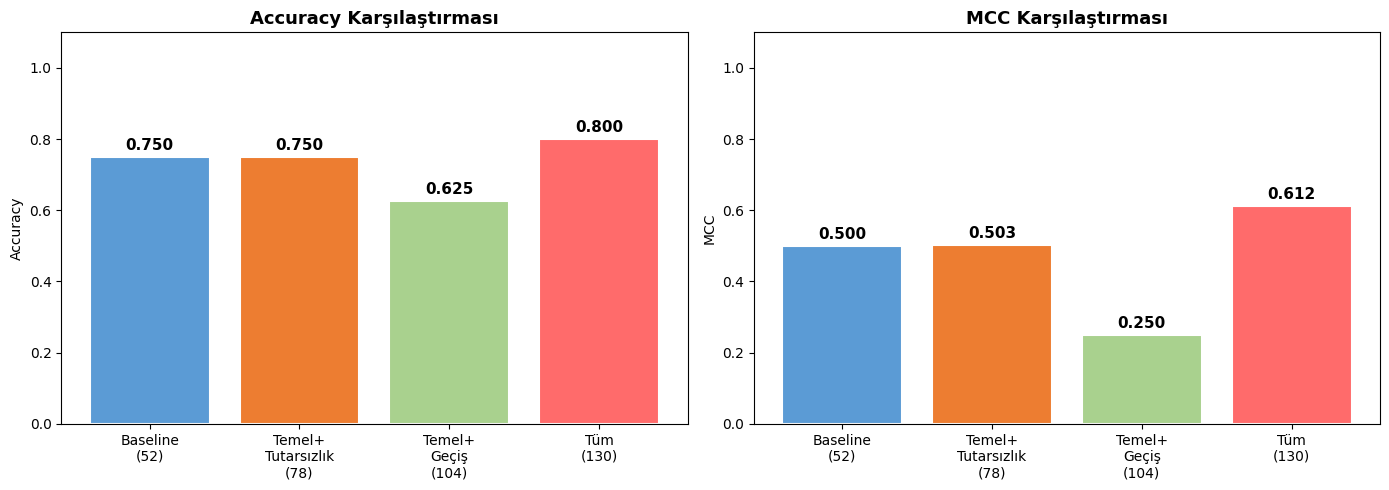

karsilastirma.png kaydedildi.


In [ ]:
# ============================================================
# GÖRSELLEŞTİRME 1: Karşılaştırma bar grafiği
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = comparison['Yöntem'].tolist()
short_names = ['Baseline\n(52)', 'Temel+\nTutarsızlık\n(78)',
               'Temel+\nGeçiş\n(104)', 'Tüm\n(130)']
colors = ['#5B9BD5', '#ED7D31', '#A9D18E', '#FF6B6B']

# Accuracy
axes[0].bar(short_names, comparison['Accuracy'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Accuracy Karşılaştırması', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# MCC
axes[1].bar(short_names, comparison['MCC'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('MCC Karşılaştırması', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MCC')
for i, v in enumerate(comparison['MCC']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print('karsilastirma.png kaydedildi.')

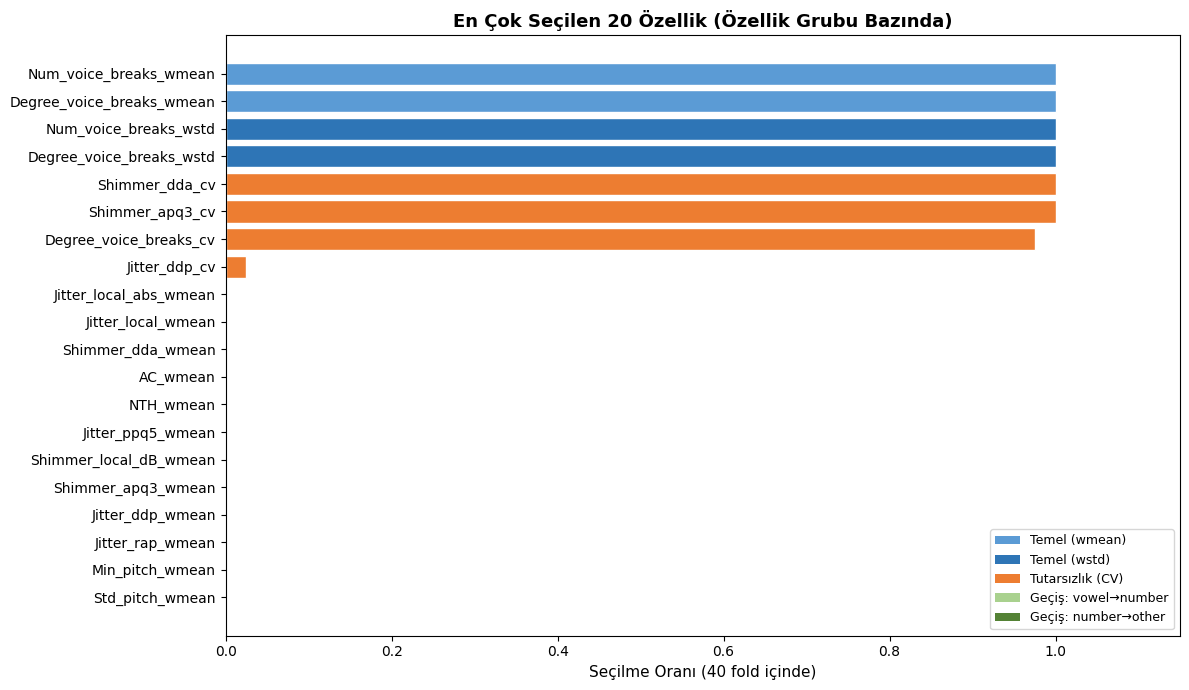

ozellik_secimi.png kaydedildi.


In [ ]:
# ============================================================
# GÖRSELLEŞTİRME 2: En çok seçilen özellikler
# ============================================================

palette = {
    'Temel (wmean)':       '#5B9BD5',
    'Temel (wstd)':        '#2E75B6',
    'Tutarsızlık (CV)':    '#ED7D31',
    'Geçiş: vowel→number': '#A9D18E',
    'Geçiş: number→other': '#548235'
}

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = [palette.get(g, '#999999') for g in top20_df['Grup']]

bars = ax.barh(top20_df['Özellik'][::-1], top20_df['Seçilme Oranı'][::-1],
               color=bar_colors[::-1], edgecolor='white')

ax.set_xlabel('Seçilme Oranı (40 fold içinde)', fontsize=11)
ax.set_title('En Çok Seçilen 20 Özellik (Özellik Grubu Bazında)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.15)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('ozellik_secimi.png', dpi=150, bbox_inches='tight')
plt.show()
print('ozellik_secimi.png kaydedildi.')

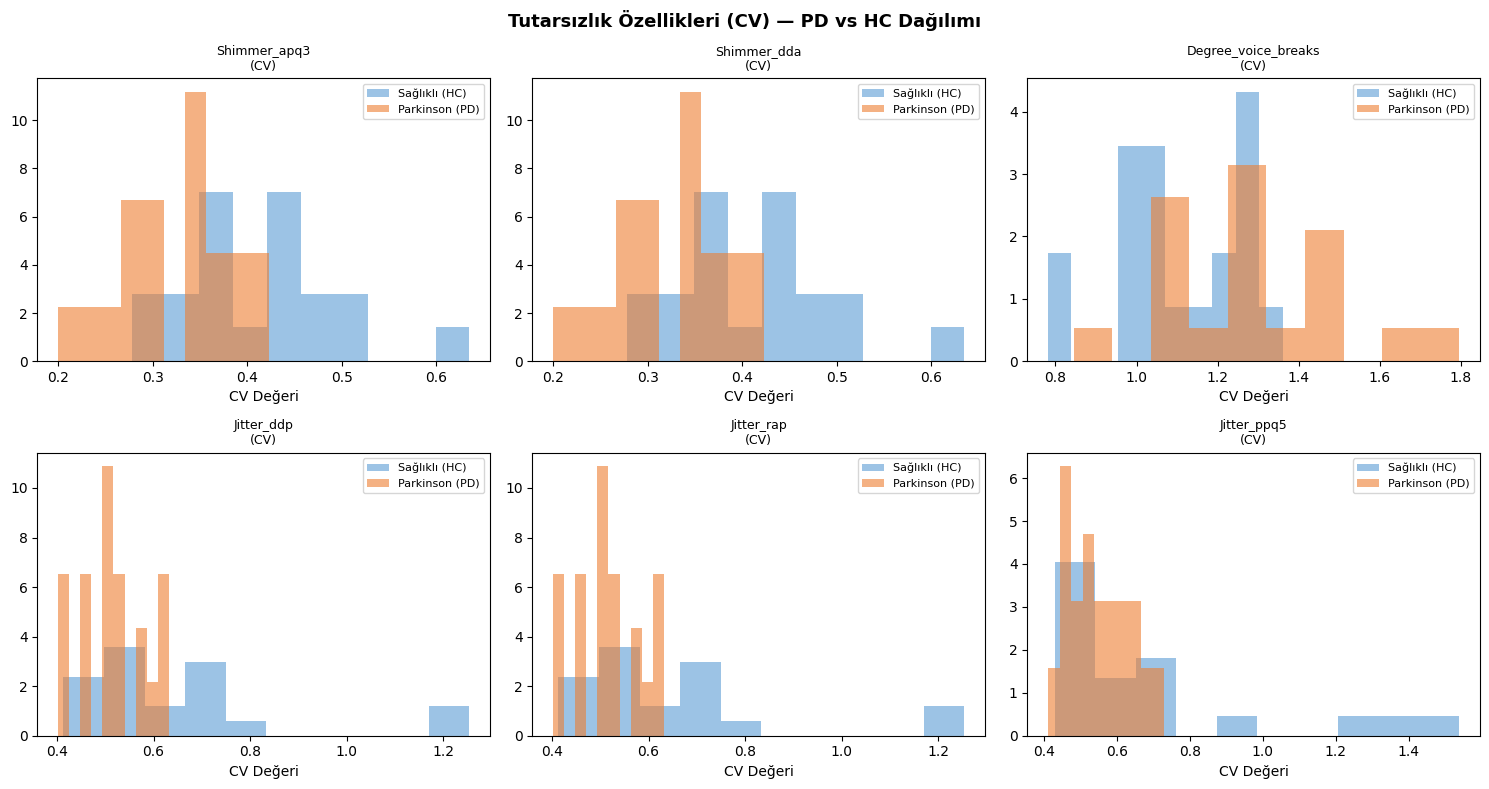

tutarsizlik_dagilim.png kaydedildi.


In [ ]:
# ============================================================
# GÖRSELLEŞTİRME 3: Tutarsızlık (CV) dağılımı — PD vs HC
# ============================================================

cv_cols = [c for c in X_df.columns if '_cv' in c]
X_cv = X_df[cv_cols].copy()
X_cv['class'] = y

# En ayırt edici CV özellikleri
cv_scores = multi_filter_score(X_df[cv_cols].values, y)
top_cv_idx = np.argsort(cv_scores)[::-1][:6]
top_cv_cols = [cv_cols[i] for i in top_cv_idx]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_cv_cols):
    hc_vals = X_cv[X_cv['class'] == 0][col]
    pd_vals = X_cv[X_cv['class'] == 1][col]

    axes[i].hist(hc_vals, bins=10, alpha=0.6, color='#5B9BD5', label='Sağlıklı (HC)', density=True)
    axes[i].hist(pd_vals, bins=10, alpha=0.6, color='#ED7D31', label='Parkinson (PD)', density=True)
    axes[i].set_title(col.replace('_cv', '\n(CV)'), fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('CV Değeri')

plt.suptitle('Tutarsızlık Özellikleri (CV) — PD vs HC Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tutarsizlik_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()
print('tutarsizlik_dagilim.png kaydedildi.')

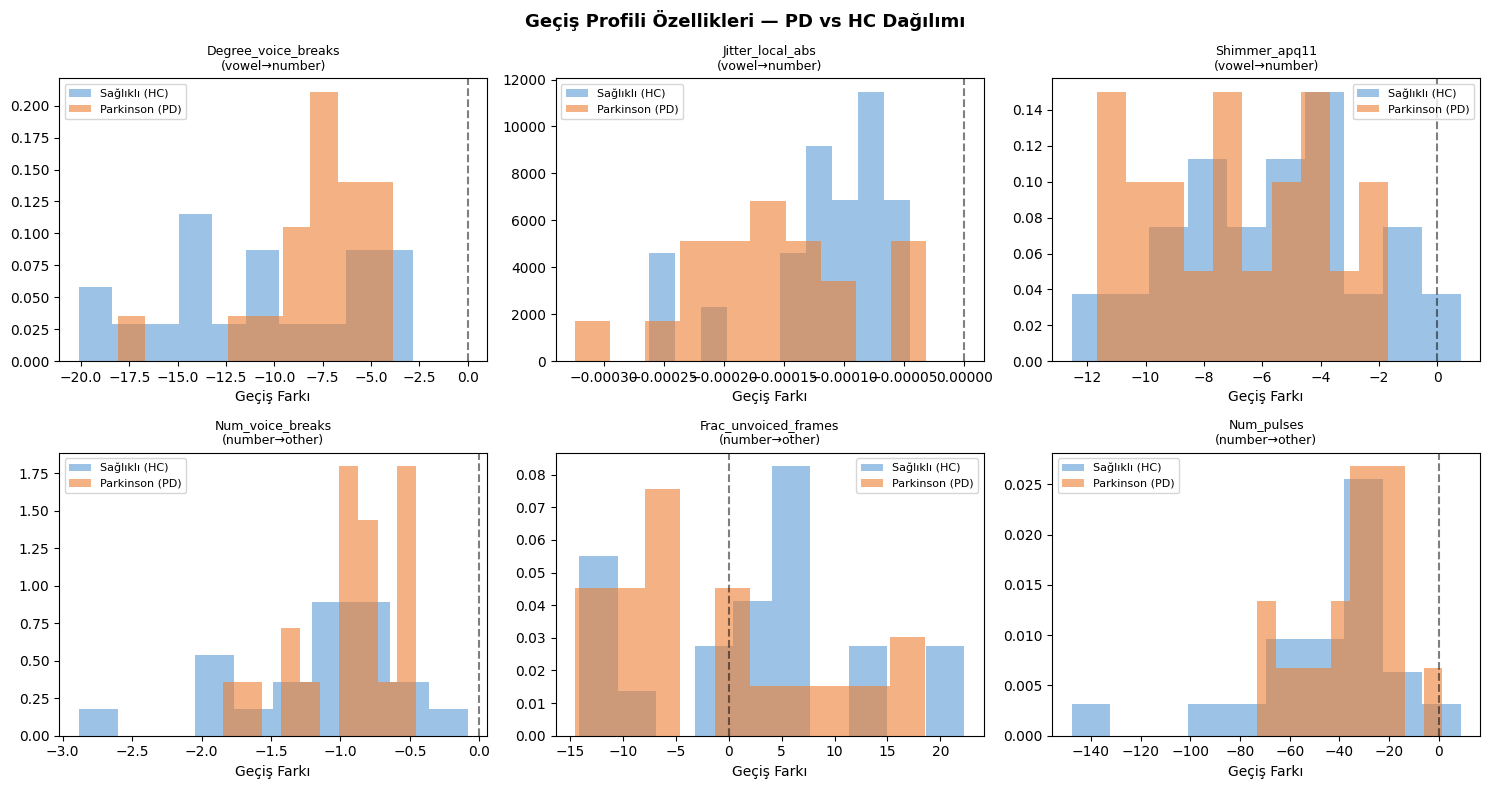

gecis_profili_dagilim.png kaydedildi.


In [ ]:
# ============================================================
# GÖRSELLEŞTİRME 4: Geçiş profili dağılımı — PD vs HC
# ============================================================

t1_cols = [c for c in X_df.columns if '_t1_' in c]
t2_cols = [c for c in X_df.columns if '_t2_' in c]

t1_scores = multi_filter_score(X_df[t1_cols].values, y)
top_t1_idx = np.argsort(t1_scores)[::-1][:3]
top_t1_cols = [t1_cols[i] for i in top_t1_idx]

t2_scores = multi_filter_score(X_df[t2_cols].values, y)
top_t2_idx = np.argsort(t2_scores)[::-1][:3]
top_t2_cols = [t2_cols[i] for i in top_t2_idx]

top_trans_cols = top_t1_cols + top_t2_cols
trans_labels = ['vowel→number'] * 3 + ['number→other'] * 3

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

X_plot = X_df.copy()
X_plot['class'] = y

for i, (col, lbl) in enumerate(zip(top_trans_cols, trans_labels)):
    hc_vals = X_plot[X_plot['class'] == 0][col]
    pd_vals = X_plot[X_plot['class'] == 1][col]

    axes[i].hist(hc_vals, bins=10, alpha=0.6, color='#5B9BD5', label='Sağlıklı (HC)', density=True)
    axes[i].hist(pd_vals, bins=10, alpha=0.6, color='#ED7D31', label='Parkinson (PD)', density=True)

    short_name = col.replace('_t1_vowel_number', '').replace('_t2_number_other', '')
    axes[i].set_title(f'{short_name}\n({lbl})', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Geçiş Farkı')
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Geçiş Profili Özellikleri — PD vs HC Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gecis_profili_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()
print('gecis_profili_dagilim.png kaydedildi.')

In [ ]:
# ============================================================
# ÖZET
# ============================================================

print('\n' + '='*70)
print('ÖZET')
print('='*70)
print(comparison.to_string(index=False))
print()
print(f'En iyi k değeri : {best_result["k"]}')
print()

print('GRUP BAZINDA EN ÇOK SEÇİLEN ÖZELLİKLER:')
print(all_features_df.groupby('Grup')['Seçilme Oranı'].agg(['mean', 'max']).round(3).sort_values('mean', ascending=False))


ÖZET
                     Yöntem  Accuracy  Sensitivity  Specificity      MCC
  Baseline (52: wmean+wstd)     0.750         0.75         0.75 0.500000
   Temel + Tutarsızlık (78)     0.750         0.70         0.80 0.502519
Temel + Geçiş Profili (104)     0.625         0.65         0.60 0.250313
       Tüm Özellikler (130)     0.800         0.70         0.90 0.612372

En iyi k değeri : 7

GRUP BAZINDA EN ÇOK SEÇİLEN ÖZELLİKLER:
                      mean  max
Grup                           
Tutarsızlık (CV)     0.115  1.0
Temel (wstd)         0.077  1.0
Temel (wmean)        0.077  1.0
Geçiş: number→other  0.000  0.0
Geçiş: vowel→number  0.000  0.0
